# 0.2 Figure 1b–d: Ru-AHK/Ru-AHO Testbed Composition

This notebook prepares the data analysis used to establish the Ru-AHK/Ru-AHO
system as a genuine low-data transfer-learning setting and generates the three
data-driven panels used in Figure 1:

- **Figure 1b:** stacked kernel-density ridgelines for the reaction-level
  $\Delta\Delta G^{\ddagger}$ distributions of outer-sphere Ru-AHK,
  inner-sphere Ru-AHK, and the inner-sphere Ru-AHO target;
- **Figure 1c:** shaded substrate coverage in pooled MACCS fingerprint PCA space;
- **Figure 1d:** shaded ligand-system coverage in pooled MACCS fingerprint PCA space.

In addition to the visual projections, the notebook quantifies:

- the reaction, substrate, and ligand-system scale of each domain and of pooled
  Ru-AHK;
- exact structural overlap between every pair of domains;
- pairwise **distribution distances** in the full MACCS fingerprint space,
  using RBF-MMD, energy distance, sliced Wasserstein distance, and symmetric
  kNN distance;
- pairwise overlap of the $\Delta\Delta G^{\ddagger}$ distributions.

The structural distance analysis follows the same metric family used in
notebook **2.1**, but is applied separately to the distributions of unique
substrates and unique ligand systems. Lower values indicate closer
distributions. PCA remains a two-dimensional visualization rather than the
quantitative similarity measure. For Figure 1c/d, each domain is shown as a
filled convex-hull region without individual scatter points, so the visual
emphasis is on structural coverage and overlap.

These quantitative checks are intended to test, rather than assume, the two
claims needed for the dataset-overview section: (i) Ru-AHO is a small target
set separated from a much larger Ru-AHK source collection, and (ii) the inner-
and outer-sphere Ru-AHK subsets are not merely two trivially disjoint structure
collections.

The source and target domains are read from:

- `data/all_ahk_Ru/processed_ahk_dataset_Ru.csv`
- `data/transfer/ru_aho_inner.csv`

All figures and source-data tables are written to:

`results/ru_ahk_aho_dataset_overview/`


In [1]:
from itertools import combinations
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import MACCSkeys
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RDLogger.DisableLog("rdApp.warning")


def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root from a notebook or script path."""
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"

PROCESSED_RU_AHK_PATH = (
    DATA_ROOT / "all_ahk_Ru" / "processed_ahk_dataset_Ru.csv"
)
RU_AHO_TARGET_PATH = DATA_ROOT / "transfer" / "ru_aho_inner.csv"

RESULTS_ROOT = PROJECT_ROOT / "results" / "ru_ahk_aho_dataset_overview"
FIGURES_ROOT = RESULTS_ROOT / "figures"
SOURCE_DATA_ROOT = RESULTS_ROOT / "source_data"

for directory in [FIGURES_ROOT, SOURCE_DATA_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

DDG_FIGURE_PATH = FIGURES_ROOT / "figure1b_selectivity_distributions.svg"
SUBSTRATE_FIGURE_PATH = (
    FIGURES_ROOT / "figure1c_substrate_chemical_space.svg"
)
LIGAND_FIGURE_PATH = (
    FIGURES_ROOT / "figure1d_ligand_system_chemical_space.svg"
)
COMBINED_FIGURE_PATH = FIGURES_ROOT / "figure1_bcd_data_panels.svg"

DDG_SOURCE_PATH = SOURCE_DATA_ROOT / "figure1b_ddg_records.csv"
DDG_DENSITY_SOURCE_PATH = SOURCE_DATA_ROOT / "figure1b_density_curves.csv"
SUBSTRATE_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "figure1c_substrate_maccs_pca.csv"
)
LIGAND_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "figure1d_ligand_system_maccs_pca.csv"
)

DATASET_SCALE_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "dataset_scale_and_unique_structures.csv"
)
STRUCTURE_OVERLAP_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "pairwise_exact_structure_overlap.csv"
)
STRUCTURE_DISTRIBUTION_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "pairwise_structure_distribution_metrics.csv"
)
DDG_OVERLAP_SOURCE_PATH = (
    SOURCE_DATA_ROOT / "pairwise_ddg_distribution_overlap.csv"
)
STRUCTURE_RELATION_FIGURE_PATH = (
    FIGURES_ROOT / "structure_relationship_diagnostic.svg"
)

RANDOM_STATE = 42
KNN_K = 10
SLICED_PROJECTIONS = 128
SLICED_QUANTILES = 256


DOMAIN_ORDER = ["ahk_outer", "ahk_inner", "aho_inner"]
DOMAIN_LABELS = {
    "ahk_outer": "Outer-sphere Ru-AHK",
    "ahk_inner": "Inner-sphere Ru-AHK",
    "aho_inner": "Inner-sphere Ru-AHO target",
}
DOMAIN_SHORT_LABELS = {
    "ahk_outer": "Ru-AHK outer",
    "ahk_inner": "Ru-AHK inner",
    "aho_inner": "Ru-AHO target",
}
DOMAIN_COLORS = {
    "ahk_outer": "#D55E00",
    "ahk_inner": "#0072B2",
    "aho_inner": "#009E73",
}
DOMAIN_MARKERS = {
    "ahk_outer": "^",
    "ahk_inner": "o",
    "aho_inner": "D",
}
DOMAIN_ZORDER = {
    "ahk_outer": 1,
    "ahk_inner": 2,
    "aho_inner": 3,
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9.5,
        "axes.labelsize": 10.5,
        "axes.titlesize": 11.5,
        "legend.fontsize": 8.6,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)


def project_relative(path: Path) -> Path:
    """Return a repository-relative path for display and manifests."""
    return path.resolve().relative_to(PROJECT_ROOT.resolve())


def resolve_column(
    table: pd.DataFrame,
    candidates: list[str],
    semantic_name: str,
) -> str:
    """Resolve a required column from common naming variants."""
    exact = {str(column): str(column) for column in table.columns}
    normalized = {
        str(column).strip().lower().replace("_", " "): str(column)
        for column in table.columns
    }

    for candidate in candidates:
        if candidate in exact:
            return exact[candidate]
        normalized_candidate = candidate.strip().lower().replace("_", " ")
        if normalized_candidate in normalized:
            return normalized[normalized_candidate]

    raise KeyError(
        f"Could not resolve the {semantic_name} column. "
        f"Tried {candidates}; available columns are {list(table.columns)}"
    )


def save_svg(fig: plt.Figure, path: Path) -> None:
    """Save a transparent-free, editable SVG with live text."""
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        facecolor="white",
    )


print(f"Ru-AHK input: {project_relative(PROCESSED_RU_AHK_PATH)}")
print(f"Ru-AHO target input: {project_relative(RU_AHO_TARGET_PATH)}")
print(f"Results: {project_relative(RESULTS_ROOT)}")


Ru-AHK input: data/all_ahk_Ru/processed_ahk_dataset_Ru.csv
Ru-AHO target input: data/transfer/ru_aho_inner.csv
Results: results/ru_ahk_aho_dataset_overview


## 1. Load and audit the mechanistically defined source and target domains

The Ru-AHK mechanism labels are taken directly from the frozen publication table and are not inferred or altered here. The Ru-AHO file is treated as the predefined inner-sphere target domain.

For downstream plotting, both files are standardized to the common columns `Reactant SMILES`, `Ligand SMILES`, `ddG`, and `Domain`.


In [2]:
for path in [PROCESSED_RU_AHK_PATH, RU_AHO_TARGET_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Required input table not found: {path}")

ru_ahk_raw = pd.read_csv(PROCESSED_RU_AHK_PATH)
ru_aho_raw = pd.read_csv(RU_AHO_TARGET_PATH)

ahk_required_columns = [
    "Reactant SMILES",
    "Ligand SMILES",
    "ddG",
    "Mechanism",
]
missing_ahk_columns = [
    column for column in ahk_required_columns
    if column not in ru_ahk_raw.columns
]
if missing_ahk_columns:
    raise KeyError(
        "Processed Ru-AHK table is missing required columns: "
        f"{missing_ahk_columns}"
    )

ru_ahk = ru_ahk_raw.loc[:, ahk_required_columns].copy()
ru_ahk["Mechanism"] = (
    ru_ahk["Mechanism"].astype(str).str.strip().str.lower()
)
ru_ahk["ddG"] = pd.to_numeric(ru_ahk["ddG"], errors="coerce")

unexpected_mechanisms = sorted(
    set(ru_ahk["Mechanism"].dropna()) - {"inner", "outer"}
)
if unexpected_mechanisms:
    raise ValueError(
        f"Unexpected Ru-AHK mechanism labels: {unexpected_mechanisms}"
    )

ru_ahk["Domain"] = ru_ahk["Mechanism"].map(
    {"inner": "ahk_inner", "outer": "ahk_outer"}
)
ru_ahk = ru_ahk.drop(columns="Mechanism")

aho_substrate_column = resolve_column(
    ru_aho_raw,
    [
        "Reactant SMILES",
        "Substrate SMILES",
        "reactant_smiles",
        "substrate_smiles",
    ],
    "Ru-AHO substrate SMILES",
)
aho_ligand_column = resolve_column(
    ru_aho_raw,
    [
        "Ligand SMILES",
        "ligand_smiles",
        "Catalyst Ligand SMILES",
        "Catalyst SMILES",
        "catalyst_smiles",
    ],
    "Ru-AHO ligand-system SMILES",
)
aho_ddg_column = resolve_column(
    ru_aho_raw,
    ["ddG", "ddg", "DDG", "DeltaDeltaG", "delta_delta_g"],
    "Ru-AHO ddG",
)

ru_aho = (
    ru_aho_raw.loc[
        :,
        [aho_substrate_column, aho_ligand_column, aho_ddg_column],
    ]
    .rename(
        columns={
            aho_substrate_column: "Reactant SMILES",
            aho_ligand_column: "Ligand SMILES",
            aho_ddg_column: "ddG",
        }
    )
    .copy()
)
ru_aho["ddG"] = pd.to_numeric(ru_aho["ddG"], errors="coerce")
ru_aho["Domain"] = "aho_inner"

for table_name, table in {
    "Ru-AHK": ru_ahk,
    "Ru-AHO target": ru_aho,
}.items():
    if table["ddG"].isna().any():
        raise ValueError(f"{table_name} contains missing ddG values.")
    if not np.isfinite(table["ddG"]).all():
        raise ValueError(f"{table_name} contains non-finite ddG values.")

if len(ru_aho) != 98:
    print(
        "Warning: the predefined Ru-AHO target domain was expected to "
        f"contain 98 rows, but {len(ru_aho)} rows were loaded."
    )

combined_domains = pd.concat(
    [
        ru_ahk.loc[:, ["Reactant SMILES", "Ligand SMILES", "ddG", "Domain"]],
        ru_aho.loc[:, ["Reactant SMILES", "Ligand SMILES", "ddG", "Domain"]],
    ],
    ignore_index=True,
)

domain_summary = (
    combined_domains.groupby("Domain", sort=False)
    .agg(
        reactions=("ddG", "size"),
        unique_substrates=("Reactant SMILES", "nunique"),
        unique_ligand_systems=("Ligand SMILES", "nunique"),
        ddG_min=("ddG", "min"),
        ddG_max=("ddG", "max"),
    )
    .reindex(DOMAIN_ORDER)
)
domain_summary.index = [
    DOMAIN_LABELS[domain] for domain in domain_summary.index
]

print(f"Final Ru-AHK rows: {len(ru_ahk)}")
print(f"Final Ru-AHO target rows: {len(ru_aho)}")
display(domain_summary.round(3))


Final Ru-AHK rows: 2034
Final Ru-AHO target rows: 98


,reactions,unique_substrates,unique_ligand_systems,ddG_min,ddG_max
Outer-sphere Ru-AHK,1539,345,304,0.000,4.526
Inner-sphere Ru-AHK,495,214,41,0.022,5.183
Inner-sphere Ru-AHO target,98,38,22,0.000,4.501


## 2. Figure 1b — selectivity distributions

A common kernel-density grid is used for all three domains. The densities are
scaled independently to equal ridge height so that distribution shape remains
legible despite the unequal sample sizes. Observed domain ranges are shown
as dashed endpoint markers and summarized in the panel labels. The
underlying reaction-level values and the plotted density curves are both
exported.


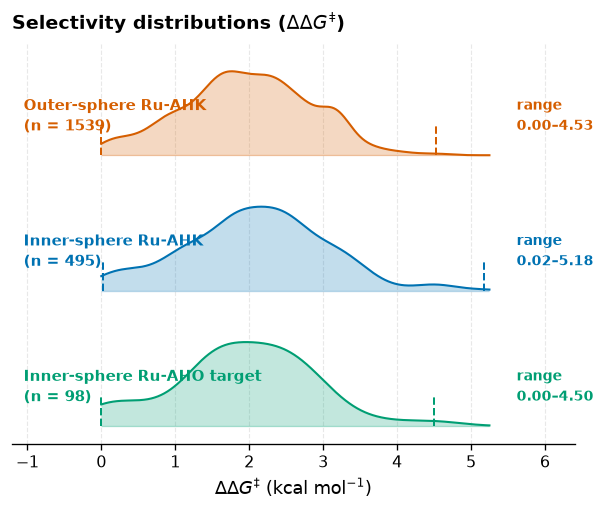

Saved: results/ru_ahk_aho_dataset_overview/figures/figure1b_selectivity_distributions.svg
Record source data: results/ru_ahk_aho_dataset_overview/source_data/figure1b_ddg_records.csv
Density source data: results/ru_ahk_aho_dataset_overview/source_data/figure1b_density_curves.csv


In [3]:
ddg_source = combined_domains.loc[:, ["Domain", "ddG"]].copy()
ddg_source.insert(0, "reaction_index", np.arange(len(ddg_source)))
ddg_source.to_csv(DDG_SOURCE_PATH, index=False)


def build_ddg_density_table(
    source: pd.DataFrame,
    n_grid: int = 600,
) -> pd.DataFrame:
    """Evaluate one KDE per domain on a common plotting grid."""
    pooled = source["ddG"].to_numpy(dtype=float)
    x_min = min(0.0, float(np.floor(pooled.min() * 4) / 4))
    x_max = float(np.ceil(pooled.max() * 4) / 4)
    if x_max <= x_min:
        x_max = x_min + 1.0

    x_grid = np.linspace(x_min, x_max, n_grid)
    density_rows = []

    for domain in DOMAIN_ORDER:
        values = source.loc[source["Domain"].eq(domain), "ddG"].to_numpy(
            dtype=float
        )
        if len(values) < 2 or np.isclose(np.std(values), 0.0):
            raise ValueError(
                f"Cannot estimate a KDE for {DOMAIN_LABELS[domain]}."
            )

        kde = gaussian_kde(values, bw_method="scott")
        density = kde(x_grid)
        density_rows.append(
            pd.DataFrame(
                {
                    "Domain": domain,
                    "x_ddG": x_grid,
                    "density": density,
                    "scaled_density": density / density.max(),
                }
            )
        )

    return pd.concat(density_rows, ignore_index=True)


ddg_density = build_ddg_density_table(ddg_source)
ddg_density.to_csv(DDG_DENSITY_SOURCE_PATH, index=False)


def draw_ddg_ridgelines(
    ax: plt.Axes,
    source: pd.DataFrame,
    density_table: pd.DataFrame,
    *,
    title: str | None = None,
    panel_label: str | None = None,
) -> None:
    """Draw the publication-style Figure 1b ridgeline panel."""
    baseline_by_domain = {
        "ahk_outer": 2.0,
        "ahk_inner": 1.0,
        "aho_inner": 0.0,
    }

    x_data_min = float(density_table["x_ddG"].min())
    x_data_max = float(density_table["x_ddG"].max())
    x_span = x_data_max - x_data_min
    left_margin = 0.23 * x_span
    right_margin = 0.22 * x_span

    for domain in DOMAIN_ORDER:
        curve = density_table.loc[
            density_table["Domain"].eq(domain)
        ].sort_values("x_ddG")
        x = curve["x_ddG"].to_numpy(dtype=float)
        scaled = curve["scaled_density"].to_numpy(dtype=float) * 0.62
        baseline = baseline_by_domain[domain]

        values = source.loc[source["Domain"].eq(domain), "ddG"].to_numpy(
            dtype=float
        )
        ddg_min = float(np.min(values))
        ddg_max = float(np.max(values))

        ax.hlines(
            baseline,
            x_data_min,
            x_data_max,
            color=DOMAIN_COLORS[domain],
            linewidth=0.8,
            alpha=0.28,
            zorder=1,
        )
        ax.fill_between(
            x,
            baseline,
            baseline + scaled,
            color=DOMAIN_COLORS[domain],
            alpha=0.24,
            linewidth=0,
            zorder=2,
        )
        ax.plot(
            x,
            baseline + scaled,
            color=DOMAIN_COLORS[domain],
            linewidth=1.25,
            zorder=3,
        )
        for endpoint in (ddg_min, ddg_max):
            ax.vlines(
                endpoint,
                baseline,
                baseline + 0.22,
                color=DOMAIN_COLORS[domain],
                linewidth=1.2,
                linestyles="--",
                zorder=4,
            )

        ax.text(
            x_data_min - 0.20 * x_span,
            baseline + 0.29,
            f"{DOMAIN_LABELS[domain]}\n(n = {len(values)})",
            ha="left",
            va="center",
            color=DOMAIN_COLORS[domain],
            fontsize=8.8,
            fontweight="bold",
            linespacing=1.35,
        )
        ax.text(
            x_data_max + 0.07 * x_span,
            baseline + 0.29,
            f"range\n{ddg_min:.2f}–{ddg_max:.2f}",
            ha="left",
            va="center",
            color=DOMAIN_COLORS[domain],
            fontsize=8.5,
            fontweight="bold",
            linespacing=1.25,
        )

    ax.set_xlim(
        x_data_min - left_margin,
        x_data_max + right_margin,
    )
    ax.set_ylim(-0.13, 2.82)
    ax.set_yticks([])
    ax.set_xlabel(r"$\Delta\Delta G^{\ddagger}$ (kcal mol$^{-1}$)")
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x", color="#B8B8B8", alpha=0.32, linestyle="--", linewidth=0.7)

    if title:
        ax.set_title(title, loc="left", fontweight="bold", pad=9)
    if panel_label:
        ax.text(
            -0.04,
            1.05,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )


fig, ax = plt.subplots(figsize=(5.2, 4.35))
draw_ddg_ridgelines(
    ax,
    ddg_source,
    ddg_density,
    title=r"Selectivity distributions ($\Delta\Delta G^{\ddagger}$)",
)
fig.tight_layout()
save_svg(fig, DDG_FIGURE_PATH)
plt.show()

print(f"Saved: {project_relative(DDG_FIGURE_PATH)}")
print(f"Record source data: {project_relative(DDG_SOURCE_PATH)}")
print(f"Density source data: {project_relative(DDG_DENSITY_SOURCE_PATH)}")


## 3. Shared MACCS–PCA workflow for Figure 1c,d

For each molecular component, PCA is fitted once on the pooled set of unique
valid structures from all three domains. Each plotted point represents one
unique **structure–domain pair**. Point area encodes the number of reaction
records containing that structure within the corresponding domain, with a
conservative upper cap to prevent highly repeated structures from dominating
the visual.

Dot-separated ligand components are retained as one ligand system, consistent
with the downstream model representation.


In [4]:
def canonicalize_smiles(smiles) -> str | None:
    """Return canonical isomeric SMILES or None for invalid input."""
    if pd.isna(smiles):
        return None
    text = str(smiles).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return None
    molecule = Chem.MolFromSmiles(text)
    if molecule is None:
        return None
    return Chem.MolToSmiles(
        molecule,
        canonical=True,
        isomericSmiles=True,
    )


def maccs_vector(smiles: str) -> np.ndarray:
    """Generate the 166 defined RDKit MACCS bits (bit 0 removed)."""
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        raise ValueError(f"Invalid canonical SMILES: {smiles}")
    fingerprint = MACCSkeys.GenMACCSKeys(molecule)
    array = np.zeros((fingerprint.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fingerprint, array)
    return array[1:].astype(float)


def build_maccs_pca_table(
    data: pd.DataFrame,
    smiles_column: str,
    structure_type: str,
) -> tuple[pd.DataFrame, np.ndarray, int]:
    """Build pooled unique-structure PCA coordinates and domain counts."""
    records = data.loc[:, [smiles_column, "Domain"]].copy()
    records["canonical_smiles"] = records[smiles_column].apply(
        canonicalize_smiles
    )
    records = records.dropna(subset=["canonical_smiles"]).reset_index(
        drop=True
    )

    counts = (
        records.groupby(
            ["canonical_smiles", "Domain"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "reaction_count"})
    )

    unique_smiles = sorted(counts["canonical_smiles"].unique())
    matrix = np.vstack([maccs_vector(smiles) for smiles in unique_smiles])

    variable_bits = matrix.var(axis=0) > 0
    if int(variable_bits.sum()) < 2:
        raise ValueError(
            f"Fewer than two variable MACCS bits for {structure_type}."
        )

    pca = PCA(n_components=2, svd_solver="full")
    coordinates = pca.fit_transform(matrix[:, variable_bits])

    coordinate_table = pd.DataFrame(
        {
            "canonical_smiles": unique_smiles,
            "PC1": coordinates[:, 0],
            "PC2": coordinates[:, 1],
        }
    )
    plot_table = counts.merge(
        coordinate_table,
        on="canonical_smiles",
        how="left",
        validate="many_to_one",
    )
    plot_table.insert(0, "structure_type", structure_type)

    return (
        plot_table,
        pca.explained_variance_ratio_,
        int(variable_bits.sum()),
    )


def domain_marker_size(reaction_count: pd.Series) -> np.ndarray:
    """Convert record counts to restrained publication-scale point areas."""
    raw = 15.0 + 9.0 * np.sqrt(reaction_count.to_numpy(dtype=float))
    return np.clip(raw, 18.0, 72.0)


def draw_structure_pca(
    ax: plt.Axes,
    plot_table: pd.DataFrame,
    explained_variance_ratio: np.ndarray,
    *,
    title: str,
    panel_label: str | None = None,
    show_legend: bool = True,
) -> None:
    """Draw shaded convex-hull coverage regions in pooled MACCS PCA space.

    Individual structures are intentionally not plotted. Each domain is shown
    only by the filled convex hull of its unique structures so that the panel
    emphasizes structural coverage and overlap rather than point density.
    """
    legend_handles = []

    for domain in DOMAIN_ORDER:
        subset = plot_table.loc[plot_table["Domain"].eq(domain)].copy()
        if subset.empty:
            continue

        points = subset[["PC1", "PC2"]].to_numpy(dtype=float)
        color = DOMAIN_COLORS[domain]

        if len(points) >= 3:
            hull = ConvexHull(points)
            hull_points = points[hull.vertices]
            ax.fill(
                hull_points[:, 0],
                hull_points[:, 1],
                facecolor=color,
                edgecolor=color,
                alpha=0.22 if domain != "aho_inner" else 0.28,
                linewidth=1.4,
                zorder=DOMAIN_ZORDER[domain],
            )
        elif len(points) == 2:
            ax.plot(
                points[:, 0],
                points[:, 1],
                color=color,
                linewidth=2.0,
                alpha=0.9,
                zorder=DOMAIN_ZORDER[domain],
            )
        else:
            ax.plot(
                points[:, 0],
                points[:, 1],
                marker="o",
                markersize=5,
                color=color,
                zorder=DOMAIN_ZORDER[domain],
            )

        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor=color,
                alpha=0.28,
                label=(
                    f"{DOMAIN_SHORT_LABELS[domain]}\n"
                    f"(unique = {len(subset)})"
                ),
            )
        )

    ax.axhline(
        0,
        color="#8F8F8F",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )
    ax.axvline(
        0,
        color="#8F8F8F",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )
    ax.set_xlabel(
        f"PC1 ({explained_variance_ratio[0] * 100:.1f}%)"
    )
    ax.set_ylabel(
        f"PC2 ({explained_variance_ratio[1] * 100:.1f}%)"
    )
    ax.set_title(title, loc="left", fontweight="bold", pad=9)
    ax.grid(color="#B8B8B8", alpha=0.20, linewidth=0.65)

    if show_legend:
        ax.legend(
            handles=legend_handles,
            frameon=False,
            loc="upper right",
            handletextpad=0.65,
            borderaxespad=0.15,
            labelspacing=0.55,
        )

    if panel_label:
        ax.text(
            -0.08,
            1.05,
            panel_label,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )

def save_individual_pca_panel(
    plot_table: pd.DataFrame,
    explained_variance_ratio: np.ndarray,
    *,
    title: str,
    output_path: Path,
) -> None:
    """Save one standalone PCA panel."""
    fig, ax = plt.subplots(figsize=(5.65, 4.45))
    draw_structure_pca(
        ax,
        plot_table,
        explained_variance_ratio,
        title=title,
    )
    fig.tight_layout()
    save_svg(fig, output_path)
    plt.show()


## 4. Quantitative checks for a genuine transfer-learning setting

The PCA panels are descriptive visualizations and should not carry the main
conclusion by themselves. This section therefore compares the **full
distributions** of unique substrates and ligand systems in MACCS fingerprint
space.

Each unique canonical structure receives equal weight, so repeated use of the
same substrate or ligand in the literature does not by itself make two domains
appear closer. For each structure type, MACCS bits that are constant across the
pooled union are removed and the remaining bits are standardized once on that
pooled unique-structure set.

Following notebook **2.1**, four complementary distribution-distance metrics
are reported:

1. **RBF-MMD**;
2. **energy distance**;
3. **sliced Wasserstein distance**;
4. **symmetric kNN distance**.

All four are distances, so **lower values indicate closer distributions**.
RBF-MMD is the main kernel distribution comparison, while the other three act
as cross-metric sensitivity checks.

The analysis answers three concrete questions:

1. Is the Ru-AHO target substantially smaller than the available Ru-AHK data?
2. How much exact structural overlap exists between each pair of domains?
3. In the overall substrate and ligand-system distributions, are inner- and
   outer-sphere Ru-AHK closer to one another than either is to Ru-AHO?


In [5]:
def build_structure_inventory(
    data: pd.DataFrame,
    smiles_column: str,
    structure_type: str,
) -> pd.DataFrame:
    """Return canonical unique structure-domain records with usage counts."""
    records = data.loc[:, [smiles_column, "Domain"]].copy()
    records["canonical_smiles"] = records[smiles_column].apply(
        canonicalize_smiles
    )
    invalid_count = int(records["canonical_smiles"].isna().sum())
    if invalid_count:
        print(
            f"Warning: excluded {invalid_count} invalid {structure_type} "
            "SMILES records."
        )
    records = records.dropna(subset=["canonical_smiles"])
    inventory = (
        records.groupby(["Domain", "canonical_smiles"], as_index=False)
        .size()
        .rename(columns={"size": "reaction_count"})
    )
    inventory.insert(0, "structure_type", structure_type)
    return inventory


def structure_sets_by_domain(
    inventory: pd.DataFrame,
) -> dict[str, set[str]]:
    """Convert a structure inventory to one canonical-SMILES set per domain."""
    return {
        domain: set(
            inventory.loc[
                inventory["Domain"].eq(domain), "canonical_smiles"
            ]
        )
        for domain in DOMAIN_ORDER
    }


def build_dataset_scale_summary(
    substrate_inventory: pd.DataFrame,
    ligand_inventory: pd.DataFrame,
) -> pd.DataFrame:
    """Summarize reaction and unique-structure scale, including pooled Ru-AHK."""
    substrate_sets = structure_sets_by_domain(substrate_inventory)
    ligand_sets = structure_sets_by_domain(ligand_inventory)
    reaction_counts = combined_domains.groupby("Domain").size().to_dict()

    rows = []
    for domain in DOMAIN_ORDER:
        rows.append(
            {
                "Domain": domain,
                "domain_label": DOMAIN_LABELS[domain],
                "reactions": int(reaction_counts[domain]),
                "unique_substrates": len(substrate_sets[domain]),
                "unique_ligand_systems": len(ligand_sets[domain]),
            }
        )

    pooled_ahk_substrates = substrate_sets["ahk_inner"] | substrate_sets["ahk_outer"]
    pooled_ahk_ligands = ligand_sets["ahk_inner"] | ligand_sets["ahk_outer"]
    rows.append(
        {
            "Domain": "ahk_all",
            "domain_label": "All Ru-AHK",
            "reactions": int(
                reaction_counts["ahk_inner"] + reaction_counts["ahk_outer"]
            ),
            "unique_substrates": len(pooled_ahk_substrates),
            "unique_ligand_systems": len(pooled_ahk_ligands),
        }
    )

    summary = pd.DataFrame(rows)
    target_row = summary.loc[summary["Domain"].eq("aho_inner")].iloc[0]
    for column in ["reactions", "unique_substrates", "unique_ligand_systems"]:
        summary[f"{column}_relative_to_target"] = (
            summary[column] / float(target_row[column])
        )
    return summary


def pairwise_exact_overlap(
    inventory: pd.DataFrame,
) -> pd.DataFrame:
    """Quantify exact canonical-SMILES overlap for every unordered domain pair."""
    structure_type = str(inventory["structure_type"].iloc[0])
    domain_sets = structure_sets_by_domain(inventory)
    rows = []
    for domain_a, domain_b in combinations(DOMAIN_ORDER, 2):
        set_a = domain_sets[domain_a]
        set_b = domain_sets[domain_b]
        intersection = set_a & set_b
        union = set_a | set_b
        rows.append(
            {
                "structure_type": structure_type,
                "domain_a": domain_a,
                "domain_b": domain_b,
                "n_a": len(set_a),
                "n_b": len(set_b),
                "n_shared": len(intersection),
                "jaccard": len(intersection) / len(union) if union else np.nan,
                "overlap_coefficient": (
                    len(intersection) / min(len(set_a), len(set_b))
                    if set_a and set_b
                    else np.nan
                ),
                "fraction_a_shared": (
                    len(intersection) / len(set_a) if set_a else np.nan
                ),
                "fraction_b_shared": (
                    len(intersection) / len(set_b) if set_b else np.nan
                ),
            }
        )
    return pd.DataFrame(rows)


def shared_rbf_gamma(reference: np.ndarray) -> float:
    """Median-distance RBF bandwidth shared by all domain pairs."""
    distances = pairwise_distances(reference, metric="euclidean")
    values = distances[np.triu_indices_from(distances, k=1)]
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) == 0:
        return 1.0
    median_distance = float(np.median(values))
    return 1.0 / (2.0 * median_distance**2 + 1e-12)


def rbf_mmd(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """Biased empirical RBF-MMD, matching notebook 2.1."""
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    value2 = float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())
    return float(np.sqrt(max(value2, 0.0)))


def multivariate_energy_distance(
    X: np.ndarray,
    Y: np.ndarray,
) -> float:
    """Multivariate energy distance in the standardized MACCS space."""
    cross = pairwise_distances(X, Y).mean()
    within_x = pairwise_distances(X, X).mean()
    within_y = pairwise_distances(Y, Y).mean()
    value = 2.0 * cross - within_x - within_y
    return float(max(value, 0.0))


def sliced_wasserstein_distance(
    X: np.ndarray,
    Y: np.ndarray,
    seed: int,
) -> float:
    """Average 1D Wasserstein-like quantile distance over random projections."""
    rng = np.random.default_rng(seed)
    directions = rng.normal(size=(SLICED_PROJECTIONS, X.shape[1]))
    directions /= (
        np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    )

    projected_x = X @ directions.T
    projected_y = Y @ directions.T
    quantiles = np.linspace(0.0, 1.0, SLICED_QUANTILES)
    qx = np.quantile(projected_x, quantiles, axis=0)
    qy = np.quantile(projected_y, quantiles, axis=0)
    return float(np.mean(np.abs(qx - qy)))


def median_knn_distance(
    reference: np.ndarray,
    query: np.ndarray,
    k: int = KNN_K,
) -> float:
    """Median mean-kNN distance from query to reference."""
    k_eff = max(1, min(int(k), len(reference)))
    model = NearestNeighbors(
        n_neighbors=k_eff,
        metric="euclidean",
    ).fit(reference)
    distances, _ = model.kneighbors(query)
    return float(np.median(distances.mean(axis=1)))


def symmetric_knn_distance(
    X: np.ndarray,
    Y: np.ndarray,
) -> float:
    """Average the two directed kNN distances so domain size is not directional."""
    return 0.5 * (
        median_knn_distance(X, Y)
        + median_knn_distance(Y, X)
    )


def standardized_maccs_distributions(
    inventory: pd.DataFrame,
) -> tuple[dict[str, np.ndarray], int, float]:
    """
    Build one standardized MACCS space from the pooled union of unique
    structures, then return one equally weighted unique-structure matrix per
    domain.
    """
    domain_sets = structure_sets_by_domain(inventory)
    union_smiles = sorted(set().union(*domain_sets.values()))
    if not union_smiles:
        raise ValueError("No valid structures are available.")

    matrix = np.vstack([maccs_vector(smiles) for smiles in union_smiles])
    variable_bits = matrix.var(axis=0) > 0
    n_variable_bits = int(variable_bits.sum())
    if n_variable_bits < 1:
        raise ValueError("No variable MACCS bits are available.")

    scaler = StandardScaler()
    union_scaled = scaler.fit_transform(matrix[:, variable_bits])
    union_scaled = np.nan_to_num(
        union_scaled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)

    row_by_smiles = {
        smiles: union_scaled[index]
        for index, smiles in enumerate(union_smiles)
    }
    by_domain = {
        domain: np.vstack(
            [row_by_smiles[smiles] for smiles in sorted(domain_sets[domain])]
        ).astype(np.float32)
        for domain in DOMAIN_ORDER
    }

    gamma = shared_rbf_gamma(union_scaled)
    return by_domain, n_variable_bits, gamma


def pairwise_structure_distribution_metrics(
    inventory: pd.DataFrame,
) -> pd.DataFrame:
    """Compare each pair of domain-level unique-structure distributions."""
    structure_type = str(inventory["structure_type"].iloc[0])
    matrices, n_variable_bits, gamma = standardized_maccs_distributions(
        inventory
    )

    rows = []
    for domain_a, domain_b in combinations(DOMAIN_ORDER, 2):
        X = matrices[domain_a]
        Y = matrices[domain_b]
        rows.append(
            {
                "structure_type": structure_type,
                "domain_a": domain_a,
                "domain_b": domain_b,
                "n_a": len(X),
                "n_b": len(Y),
                "n_variable_maccs_bits": n_variable_bits,
                "rbf_gamma": gamma,
                "rbf_mmd": rbf_mmd(X, Y, gamma),
                "energy_distance": multivariate_energy_distance(X, Y),
                "sliced_wasserstein": sliced_wasserstein_distance(
                    X,
                    Y,
                    seed=RANDOM_STATE,
                ),
                "symmetric_knn_distance": symmetric_knn_distance(X, Y),
            }
        )
    return pd.DataFrame(rows)


def pairwise_ddg_distribution_overlap(
    data: pd.DataFrame,
    n_grid: int = 2000,
) -> pd.DataFrame:
    """Quantify pairwise label overlap on one common KDE grid."""
    pooled = data["ddG"].to_numpy(dtype=float)
    spread = max(float(np.std(pooled)), 0.25)
    x_grid = np.linspace(
        float(np.min(pooled) - 0.5 * spread),
        float(np.max(pooled) + 0.5 * spread),
        n_grid,
    )
    rows = []
    for domain_a, domain_b in combinations(DOMAIN_ORDER, 2):
        values_a = data.loc[data["Domain"].eq(domain_a), "ddG"].to_numpy()
        values_b = data.loc[data["Domain"].eq(domain_b), "ddG"].to_numpy()
        density_a = gaussian_kde(values_a)(x_grid)
        density_b = gaussian_kde(values_b)(x_grid)
        density_a /= np.trapezoid(density_a, x_grid)
        density_b /= np.trapezoid(density_b, x_grid)
        rows.append(
            {
                "domain_a": domain_a,
                "domain_b": domain_b,
                "kde_overlap_coefficient": float(
                    np.trapezoid(np.minimum(density_a, density_b), x_grid)
                ),
                "wasserstein_distance_kcal_mol": float(
                    wasserstein_distance(values_a, values_b)
                ),
                "median_difference_kcal_mol": float(
                    np.median(values_a) - np.median(values_b)
                ),
            }
        )
    return pd.DataFrame(rows)


substrate_inventory = build_structure_inventory(
    combined_domains,
    smiles_column="Reactant SMILES",
    structure_type="substrate",
)
ligand_inventory = build_structure_inventory(
    combined_domains,
    smiles_column="Ligand SMILES",
    structure_type="ligand-system",
)

dataset_scale_summary = build_dataset_scale_summary(
    substrate_inventory,
    ligand_inventory,
)
exact_overlap_summary = pd.concat(
    [
        pairwise_exact_overlap(substrate_inventory),
        pairwise_exact_overlap(ligand_inventory),
    ],
    ignore_index=True,
)
structure_distribution_metrics = pd.concat(
    [
        pairwise_structure_distribution_metrics(substrate_inventory),
        pairwise_structure_distribution_metrics(ligand_inventory),
    ],
    ignore_index=True,
)
ddg_overlap_summary = pairwise_ddg_distribution_overlap(combined_domains)

dataset_scale_summary.to_csv(DATASET_SCALE_SOURCE_PATH, index=False)
exact_overlap_summary.to_csv(STRUCTURE_OVERLAP_SOURCE_PATH, index=False)
structure_distribution_metrics.to_csv(
    STRUCTURE_DISTRIBUTION_SOURCE_PATH,
    index=False,
)
ddg_overlap_summary.to_csv(DDG_OVERLAP_SOURCE_PATH, index=False)

print("Dataset scale and pooled unique-structure counts")
display(dataset_scale_summary.round(3))
print("Exact canonical-structure overlap")
display(exact_overlap_summary.round(3))
print("Pairwise distribution distances in standardized MACCS space")
display(structure_distribution_metrics.round(4))
print("Pairwise selectivity-label overlap")
display(ddg_overlap_summary.round(3))


Dataset scale and pooled unique-structure counts


,Domain,domain_label,reactions,unique_substrates,unique_ligand_systems,reactions_relative_to_target,unique_substrates_relative_to_target,unique_ligand_systems_relative_to_target
0,ahk_outer,Outer-sphere Ru-AHK,1539,345,304,15.704,9.079,13.818
1,ahk_inner,Inner-sphere Ru-AHK,495,214,41,5.051,5.632,1.864
2,aho_inner,Inner-sphere Ru-AHO target,98,38,22,1.000,1.000,1.000
3,ahk_all,All Ru-AHK,2034,527,345,20.755,13.868,15.682


Exact canonical-structure overlap


,structure_type,domain_a,domain_b,n_a,n_b,n_shared,jaccard,overlap_coefficient,fraction_a_shared,fraction_b_shared
0,substrate,ahk_outer,ahk_inner,345,214,32,0.061,0.150,0.093,0.150
1,substrate,ahk_outer,aho_inner,345,38,0,0.000,0.000,0.000,0.000
2,substrate,ahk_inner,aho_inner,214,38,0,0.000,0.000,0.000,0.000
3,ligand-system,ahk_outer,ahk_inner,304,41,0,0.000,0.000,0.000,0.000
4,ligand-system,ahk_outer,aho_inner,304,22,2,0.006,0.091,0.007,0.091
5,ligand-system,ahk_inner,aho_inner,41,22,1,0.016,0.045,0.024,0.045


Pairwise distribution distances in standardized MACCS space


,structure_type,domain_a,domain_b,n_a,n_b,n_variable_maccs_bits,rbf_gamma,rbf_mmd,energy_distance,sliced_wasserstein,symmetric_knn_distance
0,substrate,ahk_outer,ahk_inner,345,214,129,0.0025,0.1700,0.8117,0.2849,8.1169
1,substrate,ahk_outer,aho_inner,345,38,129,0.0025,0.4428,5.3058,0.6886,11.5494
2,substrate,ahk_inner,aho_inner,214,38,129,0.0025,0.4255,4.9039,0.6494,11.1530
3,ligand-system,ahk_outer,ahk_inner,304,41,140,0.0023,0.4074,4.5417,0.6161,13.9330
4,ligand-system,ahk_outer,aho_inner,304,22,140,0.0023,0.4315,5.4306,0.7125,13.3385
5,ligand-system,ahk_inner,aho_inner,41,22,140,0.0023,0.3624,4.2099,0.6383,15.2928


Pairwise selectivity-label overlap


,domain_a,domain_b,kde_overlap_coefficient,wasserstein_distance_kcal_mol,median_difference_kcal_mol
0,ahk_outer,ahk_inner,0.933,0.123,-0.167
1,ahk_outer,aho_inner,0.937,0.110,0.002
2,ahk_inner,aho_inner,0.939,0.178,0.169


### Interpretation guardrails

The quantitative tables should determine the wording used in the manuscript.

- PCA is only a visual projection. The structural comparison should be based on
  the four distribution distances calculated in the full standardized MACCS
  space.
- For all four structural metrics, **lower means closer**.
- A conclusion that the two Ru-AHK mechanism subsets are structurally closer
  to one another is strongest when the same ordering is reproduced across
  several metrics rather than inferred from one score.
- Substrate and ligand-system spaces should be interpreted separately. If the
  ordering is supported for substrates but not ligands, the manuscript should
  say so rather than make a blanket statement about chemical-space similarity.
  Because the two structure types are standardized separately, absolute metric
  magnitudes should not be compared across the substrate and ligand-system rows.
- Exact canonical-SMILES overlap remains a useful descriptive statistic, but
  it is not used as the distribution-distance metric.
- Each unique structure is weighted once in these comparisons. The metrics
  therefore describe coverage of chemical structure space rather than
  literature sampling frequency.


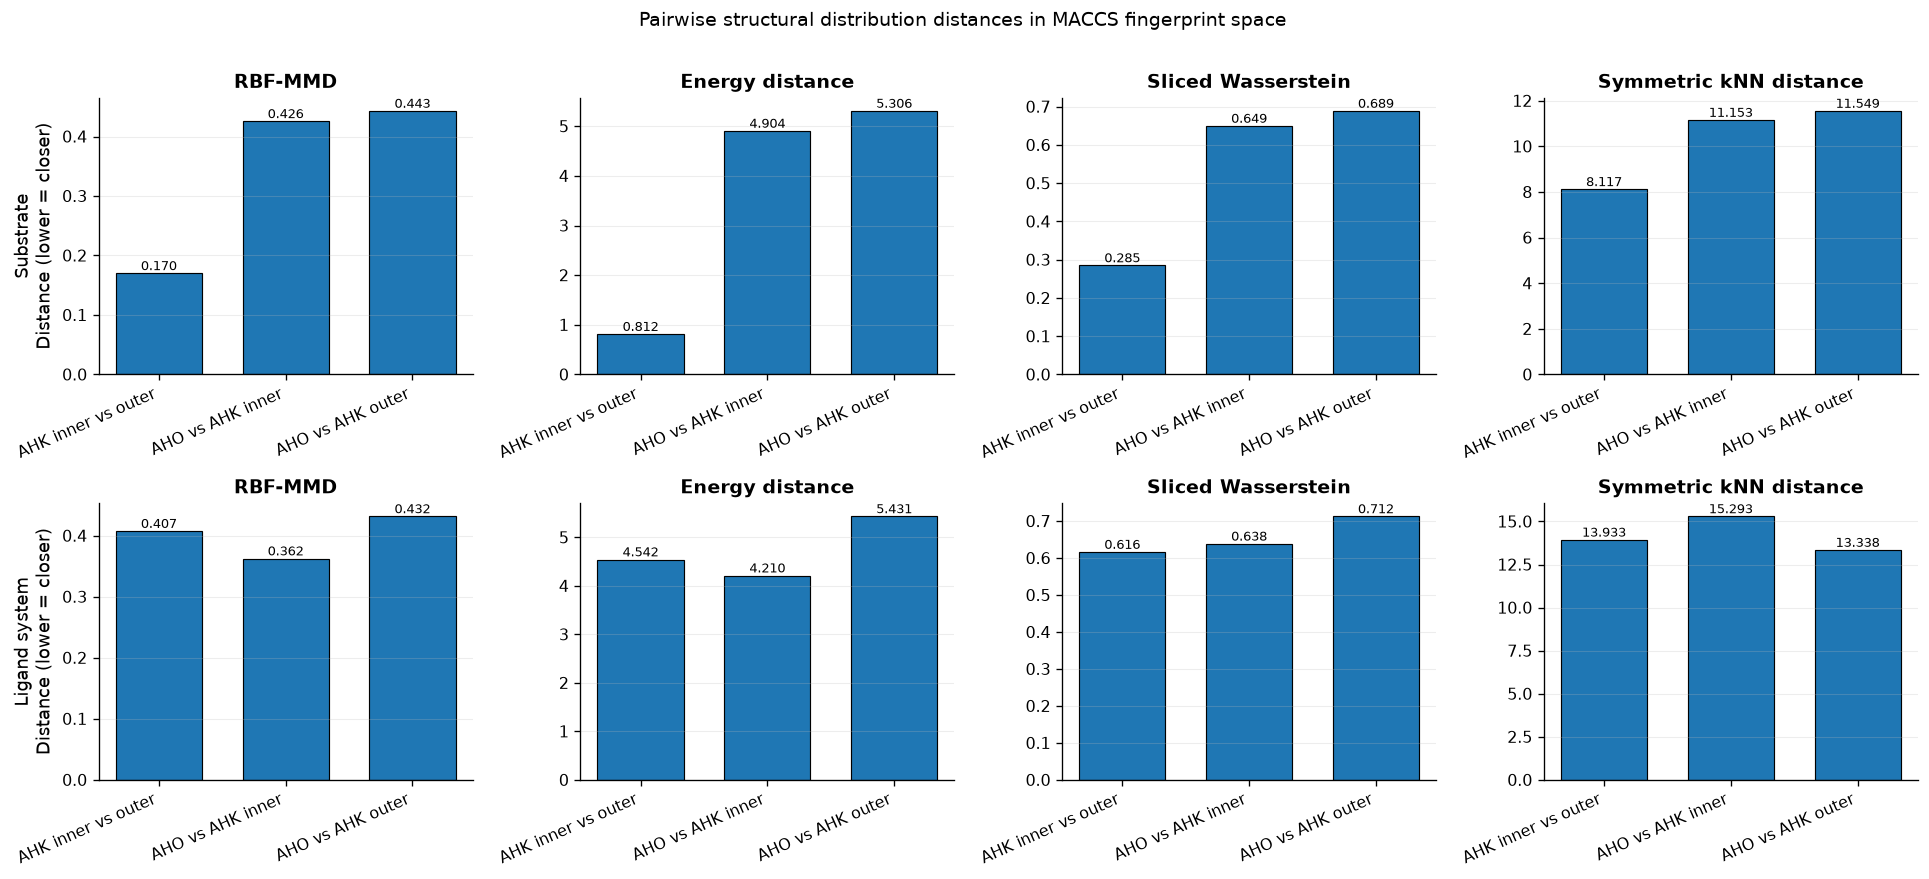

Saved: results/ru_ahk_aho_dataset_overview/figures/structure_relationship_diagnostic.svg


,structure_type,metric,AHK_inner_vs_outer,AHO_vs_AHK_inner,AHO_vs_AHK_outer,AHK_pair_closer_than_both_AHO_pairs
0,substrate,RBF-MMD,0.1700,0.4255,0.4428,True
1,substrate,Energy distance,0.8117,4.9039,5.3058,True
2,substrate,Sliced Wasserstein,0.2849,0.6494,0.6886,True
3,substrate,Symmetric kNN distance,8.1169,11.1530,11.5494,True
4,ligand-system,RBF-MMD,0.4074,0.3624,0.4315,False
5,ligand-system,Energy distance,4.5417,4.2099,5.4306,False
6,ligand-system,Sliced Wasserstein,0.6161,0.6383,0.7125,True
7,ligand-system,Symmetric kNN distance,13.9330,15.2928,13.3385,False


Pooled Ru-AHK / Ru-AHO reaction-count ratio: 20.8x


In [6]:
PAIR_DISPLAY_LABELS = {
    tuple(sorted(("ahk_outer", "ahk_inner"))): "AHK inner vs outer",
    tuple(sorted(("ahk_outer", "aho_inner"))): "AHO vs AHK outer",
    tuple(sorted(("ahk_inner", "aho_inner"))): "AHO vs AHK inner",
}


def add_pair_label(table: pd.DataFrame) -> pd.DataFrame:
    result = table.copy()
    result["pair_key"] = [
        tuple(sorted((domain_a, domain_b)))
        for domain_a, domain_b in zip(result["domain_a"], result["domain_b"])
    ]
    result["pair_label"] = result["pair_key"].map(PAIR_DISPLAY_LABELS)
    return result


distribution_plot_table = add_pair_label(structure_distribution_metrics)
pair_order = [
    "AHK inner vs outer",
    "AHO vs AHK inner",
    "AHO vs AHK outer",
]

STRUCTURE_METRIC_LABELS = {
    "rbf_mmd": "RBF-MMD",
    "energy_distance": "Energy distance",
    "sliced_wasserstein": "Sliced Wasserstein",
    "symmetric_knn_distance": "Symmetric kNN distance",
}

fig, axes = plt.subplots(
    2,
    len(STRUCTURE_METRIC_LABELS),
    figsize=(16.2, 7.2),
    squeeze=False,
)

for row_index, (structure_type, row_label) in enumerate(
    [
        ("substrate", "Substrate"),
        ("ligand-system", "Ligand system"),
    ]
):
    for column_index, (metric_id, metric_label) in enumerate(
        STRUCTURE_METRIC_LABELS.items()
    ):
        ax = axes[row_index, column_index]
        subset = (
            distribution_plot_table.loc[
                distribution_plot_table["structure_type"].eq(structure_type)
            ]
            .set_index("pair_label")
            .reindex(pair_order)
            .reset_index()
        )

        x = np.arange(len(subset))
        bars = ax.bar(
            x,
            subset[metric_id],
            width=0.68,
            edgecolor="black",
            linewidth=0.7,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(
            subset["pair_label"],
            rotation=24,
            ha="right",
        )
        ax.set_title(metric_label, fontweight="bold")
        ax.grid(axis="y", color="#B8B8B8", alpha=0.25, linewidth=0.65)

        if column_index == 0:
            ax.set_ylabel(f"{row_label}\nDistance (lower = closer)")

        for bar, value in zip(bars, subset[metric_id].to_numpy(dtype=float)):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

fig.suptitle(
    "Pairwise structural distribution distances in MACCS fingerprint space",
    y=1.01,
)
fig.tight_layout()
save_svg(fig, STRUCTURE_RELATION_FIGURE_PATH)
plt.show()

print(f"Saved: {project_relative(STRUCTURE_RELATION_FIGURE_PATH)}")

# Print the observed ordering without forcing a predetermined conclusion.
comparison_rows = []
for structure_type in ["substrate", "ligand-system"]:
    subset = distribution_plot_table.loc[
        distribution_plot_table["structure_type"].eq(structure_type)
    ].set_index("pair_label")

    for metric_id, metric_label in STRUCTURE_METRIC_LABELS.items():
        ahk_pair = float(subset.loc["AHK inner vs outer", metric_id])
        aho_inner = float(subset.loc["AHO vs AHK inner", metric_id])
        aho_outer = float(subset.loc["AHO vs AHK outer", metric_id])
        comparison_rows.append(
            {
                "structure_type": structure_type,
                "metric": metric_label,
                "AHK_inner_vs_outer": ahk_pair,
                "AHO_vs_AHK_inner": aho_inner,
                "AHO_vs_AHK_outer": aho_outer,
                "AHK_pair_closer_than_both_AHO_pairs": bool(
                    ahk_pair < aho_inner and ahk_pair < aho_outer
                ),
            }
        )

distribution_ordering_summary = pd.DataFrame(comparison_rows)
display(distribution_ordering_summary.round(4))

all_ahk_row = dataset_scale_summary.loc[
    dataset_scale_summary["Domain"].eq("ahk_all")
].iloc[0]
print(
    "Pooled Ru-AHK / Ru-AHO reaction-count ratio: "
    f"{all_ahk_row['reactions_relative_to_target']:.1f}x"
)


## 5. Figure 1c — substrate chemical-space coverage

The substrate projection is fitted to pooled unique canonicalized
`Reactant SMILES` values from the two Ru-AHK source domains and the Ru-AHO
target domain. The panel displays only the shaded convex-hull coverage of each
domain in the common PCA projection; individual structures are not shown.


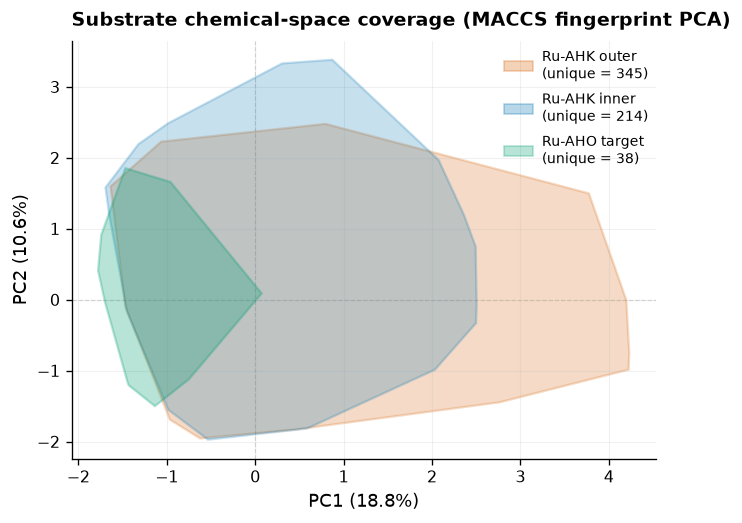

Substrate PCA used 129 variable MACCS bits.
Explained variance: PC1=0.1881, PC2=0.1055
Saved: results/ru_ahk_aho_dataset_overview/figures/figure1c_substrate_chemical_space.svg
Source data: results/ru_ahk_aho_dataset_overview/source_data/figure1c_substrate_maccs_pca.csv


In [7]:
substrate_pca, substrate_variance, substrate_variable_bits = (
    build_maccs_pca_table(
        combined_domains,
        smiles_column="Reactant SMILES",
        structure_type="substrate",
    )
)
substrate_pca.to_csv(SUBSTRATE_SOURCE_PATH, index=False)

save_individual_pca_panel(
    substrate_pca,
    substrate_variance,
    title="Substrate chemical-space coverage (MACCS fingerprint PCA)",
    output_path=SUBSTRATE_FIGURE_PATH,
)

print(
    f"Substrate PCA used {substrate_variable_bits} variable MACCS bits."
)
print(
    "Explained variance: "
    f"PC1={substrate_variance[0]:.4f}, "
    f"PC2={substrate_variance[1]:.4f}"
)
print(f"Saved: {project_relative(SUBSTRATE_FIGURE_PATH)}")
print(f"Source data: {project_relative(SUBSTRATE_SOURCE_PATH)}")


## 6. Figure 1d — ligand-system chemical-space coverage

The ligand-system projection uses the complete `Ligand SMILES` entry for every
reaction. Dot-separated ligand components remain one catalyst ligand system.
As in the substrate panel, only the shaded convex-hull coverage of each domain
is shown, with no individual scatter points.


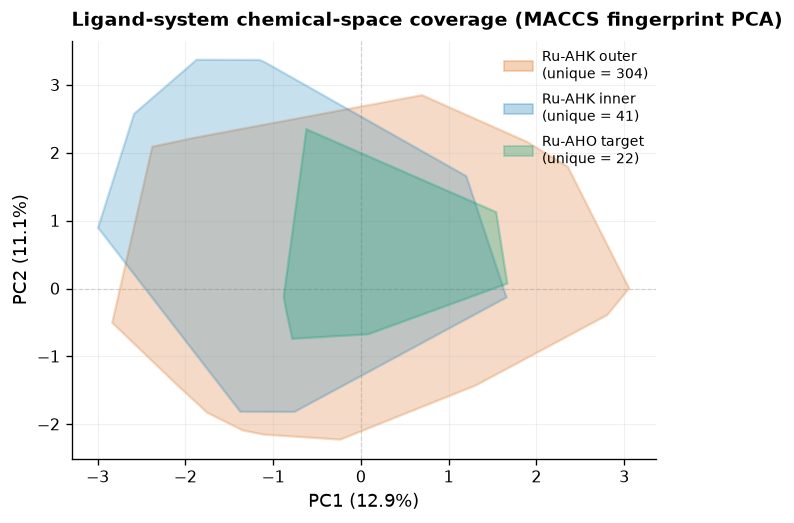

Ligand PCA used 140 variable MACCS bits.
Explained variance: PC1=0.1286, PC2=0.1110
Saved: results/ru_ahk_aho_dataset_overview/figures/figure1d_ligand_system_chemical_space.svg
Source data: results/ru_ahk_aho_dataset_overview/source_data/figure1d_ligand_system_maccs_pca.csv


In [8]:
ligand_pca, ligand_variance, ligand_variable_bits = (
    build_maccs_pca_table(
        combined_domains,
        smiles_column="Ligand SMILES",
        structure_type="ligand-system",
    )
)
ligand_pca.to_csv(LIGAND_SOURCE_PATH, index=False)

save_individual_pca_panel(
    ligand_pca,
    ligand_variance,
    title="Ligand-system chemical-space coverage (MACCS fingerprint PCA)",
    output_path=LIGAND_FIGURE_PATH,
)

print(
    f"Ligand PCA used {ligand_variable_bits} variable MACCS bits."
)
print(
    "Explained variance: "
    f"PC1={ligand_variance[0]:.4f}, "
    f"PC2={ligand_variance[1]:.4f}"
)
print(f"Saved: {project_relative(LIGAND_FIGURE_PATH)}")
print(f"Source data: {project_relative(LIGAND_SOURCE_PATH)}")


## 7. Combined Figure 1b–d data-panel preview

This preview uses the same plotting functions and source tables as the
standalone SVG panels. It is intended for direct comparison with the
planned Figure 1 layout; the chemical-mechanism panel (Figure 1a) remains
assembled separately.


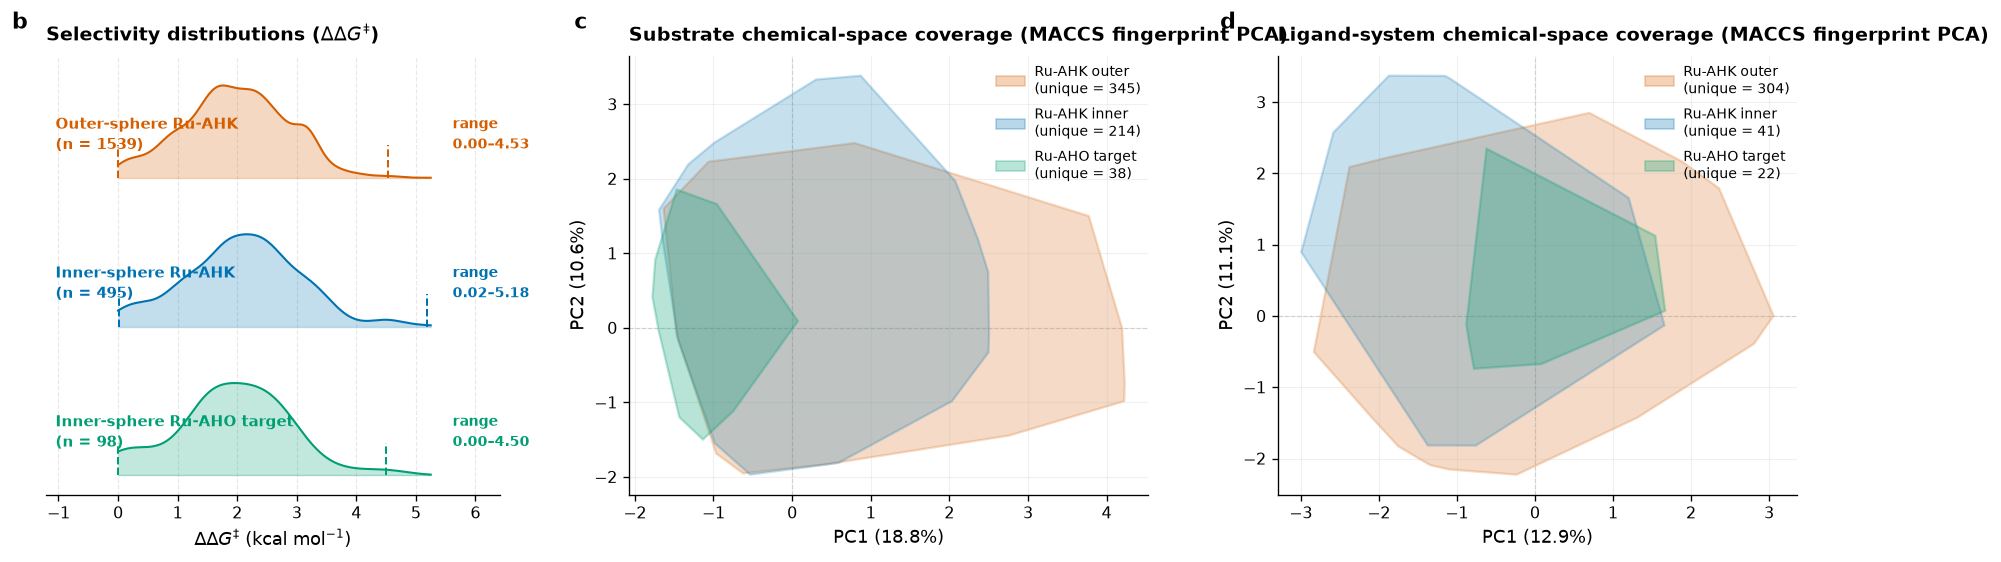

Saved: results/ru_ahk_aho_dataset_overview/figures/figure1_bcd_data_panels.svg


In [9]:
fig = plt.figure(figsize=(15.2, 4.75))
grid = fig.add_gridspec(
    1,
    3,
    width_ratios=[0.96, 1.10, 1.10],
    wspace=0.26,
)

ax_b = fig.add_subplot(grid[0, 0])
ax_c = fig.add_subplot(grid[0, 1])
ax_d = fig.add_subplot(grid[0, 2])

draw_ddg_ridgelines(
    ax_b,
    ddg_source,
    ddg_density,
    title=r"Selectivity distributions ($\Delta\Delta G^{\ddagger}$)",
    panel_label="b",
)
draw_structure_pca(
    ax_c,
    substrate_pca,
    substrate_variance,
    title="Substrate chemical-space coverage (MACCS fingerprint PCA)",
    panel_label="c",
)
draw_structure_pca(
    ax_d,
    ligand_pca,
    ligand_variance,
    title="Ligand-system chemical-space coverage (MACCS fingerprint PCA)",
    panel_label="d",
)

fig.subplots_adjust(left=0.035, right=0.995, bottom=0.15, top=0.92)
save_svg(fig, COMBINED_FIGURE_PATH)
plt.show()

print(f"Saved: {project_relative(COMBINED_FIGURE_PATH)}")


## 8. Output validation

The final cell verifies that all panel-ready and combined SVG files are
present and XML-parseable, and that all source-data tables contain the expected
domains and finite coordinates.


In [10]:
expected_figures = [
    DDG_FIGURE_PATH,
    SUBSTRATE_FIGURE_PATH,
    LIGAND_FIGURE_PATH,
    COMBINED_FIGURE_PATH,
    STRUCTURE_RELATION_FIGURE_PATH,
]
expected_source_tables = [
    DDG_SOURCE_PATH,
    DDG_DENSITY_SOURCE_PATH,
    SUBSTRATE_SOURCE_PATH,
    LIGAND_SOURCE_PATH,
    DATASET_SCALE_SOURCE_PATH,
    STRUCTURE_OVERLAP_SOURCE_PATH,
    STRUCTURE_DISTRIBUTION_SOURCE_PATH,
    DDG_OVERLAP_SOURCE_PATH,
]

for path in expected_figures:
    if not path.exists():
        raise FileNotFoundError(f"Expected figure was not written: {path}")
    ET.parse(path)

for path in expected_source_tables:
    if not path.exists():
        raise FileNotFoundError(
            f"Expected source-data table was not written: {path}"
        )

for table_name, table in {
    "substrate PCA": substrate_pca,
    "ligand PCA": ligand_pca,
}.items():
    if not np.isfinite(table[["PC1", "PC2"]].to_numpy()).all():
        raise ValueError(f"{table_name} contains non-finite coordinates.")
    observed_domains = set(table["Domain"].dropna())
    missing_domains = set(DOMAIN_ORDER) - observed_domains
    if missing_domains:
        raise ValueError(
            f"{table_name} is missing expected domains: {missing_domains}"
        )

for table_name, table in {
    "ddG records": ddg_source,
    "ddG density curves": ddg_density,
}.items():
    observed_domains = set(table["Domain"].dropna())
    missing_domains = set(DOMAIN_ORDER) - observed_domains
    if missing_domains:
        raise ValueError(
            f"{table_name} is missing expected domains: {missing_domains}"
        )

if not np.isfinite(
    ddg_density[["x_ddG", "density", "scaled_density"]].to_numpy()
).all():
    raise ValueError("ddG density source data contain non-finite values.")

output_manifest_rows = [
    ("figure", "Figure 1b selectivity distributions", DDG_FIGURE_PATH),
    ("figure", "Figure 1c substrate MACCS-PCA", SUBSTRATE_FIGURE_PATH),
    ("figure", "Figure 1d ligand-system MACCS-PCA", LIGAND_FIGURE_PATH),
    ("figure", "Combined Figure 1b-d preview", COMBINED_FIGURE_PATH),
    (
        "figure",
        "Quantitative structure-relationship diagnostic",
        STRUCTURE_RELATION_FIGURE_PATH,
    ),
    ("source_data", "Figure 1b reaction-level ddG values", DDG_SOURCE_PATH),
    (
        "source_data",
        "Figure 1b plotted density curves",
        DDG_DENSITY_SOURCE_PATH,
    ),
    (
        "source_data",
        "Figure 1c substrate PCA source data",
        SUBSTRATE_SOURCE_PATH,
    ),
    (
        "source_data",
        "Figure 1d ligand-system PCA source data",
        LIGAND_SOURCE_PATH,
    ),
    (
        "source_data",
        "Dataset scale and pooled unique-structure counts",
        DATASET_SCALE_SOURCE_PATH,
    ),
    (
        "source_data",
        "Pairwise exact structure overlap",
        STRUCTURE_OVERLAP_SOURCE_PATH,
    ),
    (
        "source_data",
        "Pairwise structural distribution-distance metrics",
        STRUCTURE_DISTRIBUTION_SOURCE_PATH,
    ),
    (
        "source_data",
        "Pairwise ddG distribution overlap",
        DDG_OVERLAP_SOURCE_PATH,
    ),
]
output_manifest = pd.DataFrame(
    [
        {
            "output_type": output_type,
            "description": description,
            "path": str(project_relative(path)),
        }
        for output_type, description, path in output_manifest_rows
    ]
)
display(output_manifest)
print("All dataset-overview figures and quantitative source tables passed validation.")


,output_type,description,path
0,figure,Figure 1b selectivity distributions,results/ru_ahk_aho_dataset_overview/figures/fi...
1,figure,Figure 1c substrate MACCS-PCA,results/ru_ahk_aho_dataset_overview/figures/fi...
2,figure,Figure 1d ligand-system MACCS-PCA,results/ru_ahk_aho_dataset_overview/figures/fi...
3,figure,Combined Figure 1b-d preview,results/ru_ahk_aho_dataset_overview/figures/fi...
4,figure,Quantitative structure-relationship diagnostic,results/ru_ahk_aho_dataset_overview/figures/st...
5,source_data,Figure 1b reaction-level ddG values,results/ru_ahk_aho_dataset_overview/source_dat...
6,source_data,Figure 1b plotted density curves,results/ru_ahk_aho_dataset_overview/source_dat...
7,source_data,Figure 1c substrate PCA source data,results/ru_ahk_aho_dataset_overview/source_dat...
8,source_data,Figure 1d ligand-system PCA source data,results/ru_ahk_aho_dataset_overview/source_dat...
9,source_data,Dataset scale and pooled unique-structure counts,results/ru_ahk_aho_dataset_overview/source_dat...


All dataset-overview figures and quantitative source tables passed validation.
